In [29]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [46]:
import numpy as np
#from ucimlrepo import fetch_ucirepo 
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
def perhitungan_triangle(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    elif a < x <= b:
        return (x - a) / (b - a)
    elif b < x < c:
        return (c - x) / (c - b)
    else:
        return 0.0

In [4]:
def perhitungan_trapezoidal(x, a, b, c, d):
    if x < a or x > d:
        return 0.0
    elif x >= b and x <= c:
        return 1.0
    elif x >= a and x < b:
        return 1.0 if b == a else (x - a) / (b - a)
    else:
        return 1.0 if d == c else (d - x) / (d - c)


In [22]:
def nilai_fsd(x):
    return {
        "tinggi" : perhitungan_trapezoidal(x,45,60,100,100),
        "sedang" : perhitungan_trapezoidal(x,20,30,45,60),
        "rendah" : perhitungan_trapezoidal(x,0,0,20,30),
    }

In [23]:
def nilai_rs(x):
    return {
        "tinggi": perhitungan_trapezoidal(x, 15, 20, 70, 70),
        "sedang": perhitungan_trapezoidal(x, 4, 5, 15, 20),
        "rendah": perhitungan_trapezoidal(x, 0, 0, 4, 5),
    }

In [24]:
def nilai_ca(x):
    return {
        "tinggi" : perhitungan_trapezoidal(x,0.40,0.50,1.66,1.66),
        "sedang" : perhitungan_trapezoidal(x,0.20,0.30,0.40,0.50),
        "rendah" : perhitungan_trapezoidal(x,0.00,0.00,0.20,0.30),
    }


In [25]:
def nilai_ph(x):
    return {
        "basa":   perhitungan_trapezoidal(x, 3.4, 3.5, 4, 4),
        "normal": perhitungan_trapezoidal(x, 3, 3.1, 3.4, 3.5),
        "asam":   perhitungan_trapezoidal(x, 2.7, 2.7, 3, 3.1),
    }

In [26]:
def nilai_sul(x):
    return {
        "tinggi": perhitungan_trapezoidal(x, 0.7, 0.8, 1.2, 1.2),
        "sedang": perhitungan_trapezoidal(x, 0.4, 0.5, 0.7, 0.8),
        "rendah": perhitungan_trapezoidal(x, 0.2, 0.2, 0.4, 0.5),
    }

In [27]:
def nilai_al(x):
    return {
        "tinggi": perhitungan_trapezoidal(x, 11, 12, 15, 15),
        "sedang": perhitungan_triangle(x, 9, 10.5, 12),
        "rendah": perhitungan_trapezoidal(x, 8, 8, 9, 10),
    }

In [40]:
range_qualitas = list(np.arange(1, 10.01, 0.1))

def qualitas(x):
    return {
        "buruk":   perhitungan_trapezoidal(x, 1, 1, 2.5, 4),
        "standar": perhitungan_triangle(x, 4, 5.5, 7),
        "bagus":   perhitungan_trapezoidal(x, 7, 8.5, 10, 10),
    }

In [41]:
def kategori_dari_nilai(v):
    if v >= 1 and v < 4:
        return "buruk"
    elif v > 4 and v <= 7:
        return "standar"
    else:
        return "bagus"


In [42]:
def proses_fuzzy(fsd, rs, ca, p, s, a):
    fsd            = nilai_fa(fsd)
    residual_sugar = nilai_rs(rs)
    citric_acid    = nilai_ca(ca)
    ph             = nilai_ph(p)
    sulphates      = nilai_sul(s)
    alkohol        = nilai_al(a)

    # ── Inferensi ──

    r1 = min(alkohol["rendah"], sulphates["rendah"])
    r2 = min(fsd["tinggi"], alkohol["rendah"])
    r3 = min(ph["asam"], alkohol["rendah"])
    r4 = min(citric_acid["rendah"], sulphates["rendah"])
    r5 = min(alkohol["rendah"], citric_acid["rendah"], fsd["tinggi"])
    r6 = min(ph["normal"], residual_sugar["sedang"], alkohol["sedang"])
    r7 = min(alkohol["sedang"], fsd["sedang"])
    r8 = min(ph["normal"], sulphates["sedang"])
    r9 = min( residual_sugar["sedang"], alkohol["sedang"])
    r10 = citric_acid["sedang"]
    r11 = min(alkohol["tinggi"], sulphates["tinggi"])
    r12 = min(alkohol["tinggi"], fsd["rendah"])
    r13 = min(alkohol["tinggi"], ph["normal"])
    r14 = min(citric_acid["tinggi"], sulphates["tinggi"])
    r15 = min(alkohol["tinggi"], citric_acid["tinggi"], fsd["rendah"])

    alpha_buruk   = max(r1, r2, r3, r4, r5)
    alpha_standar = max(r6, r7, r8, r9, r10)
    alpha_bagus   = max(r11, r12, r13, r14, r15)

    # ── Mamdani (centroid) ──
    clip_buruk, clip_standar, clip_bagus = [], [], []
    for nilai in range_qualitas:
        mu = qualitas(nilai)
        clip_buruk.append(min(alpha_buruk, mu["buruk"]))
        clip_standar.append(min(alpha_standar, mu["standar"]))
        clip_bagus.append(min(alpha_bagus, mu["bagus"]))

    tot_Bi = tot_zxBi = 0
    for i, nilai in enumerate(range_qualitas):
        z = max(clip_bagus[i], clip_buruk[i], clip_standar[i])
        tot_Bi   += z
        tot_zxBi += nilai * z

    mamdani = tot_zxBi / tot_Bi if tot_Bi != 0 else 0

    # ── Sugeno (WA) ──
    tot_Bi_s   = alpha_bagus + alpha_buruk + alpha_standar
    sugeno     = ((alpha_bagus * 8.5) + (alpha_standar * 5.5) + (alpha_buruk * 2.5)) / tot_Bi_s if tot_Bi_s != 0 else 0

    return {
        "mamdani":        mamdani,
        "sugeno":         sugeno,
        "alpha_buruk":    alpha_buruk,
        "alpha_standar":  alpha_standar,
        "alpha_bagus":    alpha_bagus,
        "kategori_mamdani": kategori_dari_nilai(mamdani),
        "kategori_sugeno":  kategori_dari_nilai(sugeno),
    }


In [49]:
df = pd.read_csv("winequality-white-indonesia.csv", sep=";", decimal=",")

records = []
for idx in range(len(df)):
    fsd = float(df["free sulfur dioxide"][idx])
    rs = float(df["residual sugar"][idx])
    ca  = float(df["citric acid"][idx])
    p  = float(df["pH"][idx])
    s  = float(df["sulphates"][idx])
    a  = float(df["alcohol"][idx])
    q  = float(df["quality"][idx])

    hasil = proses_fuzzy(fsd, rs, ca, p, s, a)

    records.append({
        "idx":                idx,
        "kualitas_asli":      q,
        "kualitas_mamdani":   round(hasil["mamdani"], 4),
        "kualitas_sugeno":    round(hasil["sugeno"], 4),
        "offset_mamdani":     round(abs(q - hasil["mamdani"]), 4),
        "offset_sugeno":      round(abs(q - hasil["sugeno"]), 4),
        "alpha_buruk":        round(hasil["alpha_buruk"], 4),
        "alpha_standar":      round(hasil["alpha_standar"], 4),
        "alpha_bagus":        round(hasil["alpha_bagus"], 4),
        "kategori_mamdani":   hasil["kategori_mamdani"],
        "kategori_sugeno":    hasil["kategori_sugeno"],
    })

hasil_df = pd.DataFrame(records)
print("doneeee")

doneeee


In [54]:
# Akurasi berdasarkan kategori
def kategori(v):
    if v <= 4:
        return "buruk"
    elif v <= 7:
        return "standar"
    else:
        return "bagus"

hasil_df["kategori_asli"] = hasil_df["kualitas_asli"].apply(kategori)

akurasi_mamdani = (hasil_df["kategori_mamdani"] == hasil_df["kategori_asli"]).mean() * 100
akurasi_sugeno  = (hasil_df["kategori_sugeno"]  == hasil_df["kategori_asli"]).mean() * 100

# Akurasi berdasarkan nilai kualitas (toleransi kurang lebih 1)
akurasi_mamdani_t = (abs(hasil_df["kualitas_mamdani"] - hasil_df["kualitas_asli"]) <= 1).mean() * 100
akurasi_sugeno_t  = (abs(hasil_df["kualitas_sugeno"]  - hasil_df["kualitas_asli"]) <= 1).mean() * 100

print("-------------------------------------- ")
print(f"|  Akurasi Mamdani kategori | {akurasi_mamdani:.2f}%  |")
print(f"|  Akurasi Sugeno kategori  | {akurasi_sugeno:.2f}%  |")
print(f"|  Akurasi Mamdani crisp    | {akurasi_mamdani_t:.2f}%  |")
print(f"|  Akurasi Sugeno crisp     | {akurasi_sugeno_t:.2f}%  |")
print("-------------------------------------- ")

-------------------------------------- 
|  Akurasi Mamdani kategori | 62.74%  |
|  Akurasi Sugeno kategori  | 77.99%  |
|  Akurasi Mamdani crisp    | 53.18%  |
|  Akurasi Sugeno crisp     | 64.21%  |
-------------------------------------- 


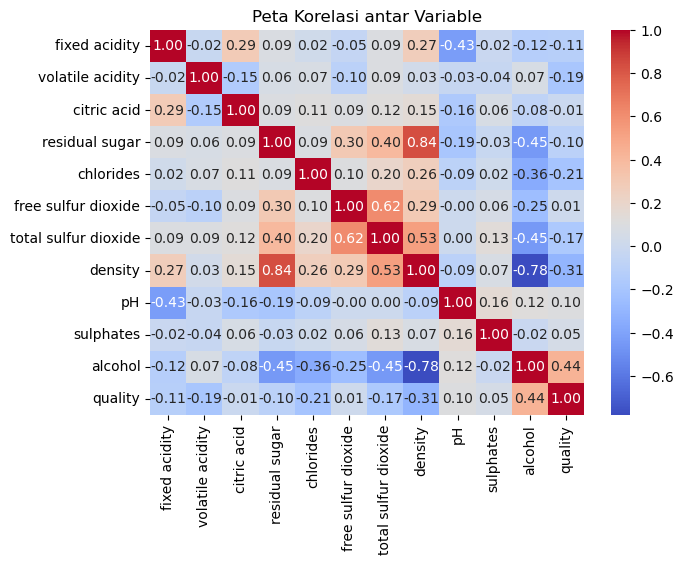

In [16]:
df = pd.read_csv("winequality-white-indonesia.csv", sep=";", decimal=",")
plt.figure(figsize=(7,5))

# Memilih hanya kolom angka untuk dihitung korelasinya
kolom_angka = df.select_dtypes(include=['int64', 'float64'])

# Membuat heatmap
sns.heatmap(kolom_angka.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Peta Korelasi antar Variable')
plt.show()

In [47]:
labels = ["buruk", "standar", "bagus"]

cm_mamdani = confusion_matrix(
    hasil_df["kategori_asli"],
    hasil_df["kategori_mamdani"],
    labels=labels
)

cm_mamdani_df = pd.DataFrame(
    cm_mamdani,
    index=[f"Asli {i}" for i in labels],
    columns=[f"Pred {i}" for i in labels]
)

print("Confusion Matrix Mamdani")
print(cm_mamdani_df)

Confusion Matrix Mamdani
              Pred buruk  Pred standar  Pred bagus
Asli buruk            53           118          12
Asli standar         951          2936         648
Asli bagus            13            83          84


In [48]:
cm_sugeno = confusion_matrix(
    hasil_df["kategori_asli"],
    hasil_df["kategori_sugeno"],
    labels=labels
)

cm_sugeno_df = pd.DataFrame(
    cm_sugeno,
    index=[f"Asli {i}" for i in labels],
    columns=[f"Pred {i}" for i in labels]
)

print("\nConfusion Matrix Sugeno")
print(cm_sugeno_df)


Confusion Matrix Sugeno
              Pred buruk  Pred standar  Pred bagus
Asli buruk            33           135          15
Asli standar         537          3770         228
Asli bagus             9           154          17
